# Day 24 — Overfitting, Underfitting, Good Fit & Model Improvement Strategies

**Dataset:** Abalone Dataset (UCI Machine Learning Repository)
**Model:** Decision Tree Classifier
**Goal:** Understand how model complexity (`max_depth` of a Decision Tree) affects
training vs. testing performance, and how to tune hyperparameters to reach a
"good fit".

### Agenda
1. Theory: Overfitting, Underfitting, Good Fit
2. Load & minimally preprocess the Abalone dataset
3. Train-test split
4. Demonstrate **Underfitting** (`max_depth=1`)
5. Demonstrate **Overfitting** (`max_depth=None`)
6. Find the **Good Fit** (optimal `max_depth`)
7. Compare training vs testing accuracy across depths
8. Hyperparameter tuning with `GridSearchCV`
9. Model Improvement Strategies
10. Practice Questions


## 1. Theory

### Underfitting
- Happens when a model is **too simple** to capture the underlying pattern in the data.
- Symptoms: **low training accuracy** and **low testing accuracy**.
- Cause: too few splits/depth, too much regularization, insufficient features.
- Example here: a Decision Tree restricted to `max_depth=1` (a "decision stump")
  can only ask one question, so it barely learns anything.

### Overfitting
- Happens when a model is **too complex** and starts memorizing the training data,
  including its noise.
- Symptoms: **very high training accuracy** but **noticeably lower testing accuracy**.
- Cause: unrestricted tree depth, too few samples per leaf, no pruning.
- Example here: a Decision Tree with `max_depth=None` grows until every leaf is
  pure (or has 1 sample), perfectly memorizing the training set.

### Good Fit
- The **sweet spot** where the model captures the true underlying pattern without
  memorizing noise.
- Symptoms: training and testing accuracy are both reasonably high and **close to
  each other**.
- Found by tuning hyperparameters like `max_depth`, `min_samples_split`,
  `min_samples_leaf`, and `criterion`, often using cross-validation.

### Bias–Variance Tradeoff
| | Bias | Variance | Train Acc | Test Acc |
|---|---|---|---|---|
| Underfitting | High | Low | Low | Low |
| Good Fit | Balanced | Balanced | High | High (close to train) |
| Overfitting | Low | High | Very High | Low (gap from train) |


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Plot style
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None
%matplotlib inline


## 2. Load the Abalone Dataset

The Abalone dataset predicts the **age** of an abalone (a sea snail) from
physical measurements. The original target `Rings` + 1.5 gives the age in years.

We load it directly from the UCI repository. Columns (per UCI documentation):

`Sex, Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, Shell weight, Rings`


In [2]:
# Load dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

columns = [
    "Sex", "Length", "Diameter", "Height", "Whole weight",
    "Shucked weight", "Viscera weight", "Shell weight", "Rings"
]

df = pd.read_csv(url, names=columns)

print(df.shape)
df.head()


(4177, 9)


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Minimal Preprocessing

We keep preprocessing to a minimum, as requested:

1. Encode the categorical `Sex` column (`M`/`F`/`I`) using `LabelEncoder`.
2. Convert the `Rings` target into a **binary classification** problem:
   - `Rings <= 10`  → **Young (0)**
   - `Rings > 10`   → **Old (1)**

   This is a common, standard simplification used for the Abalone dataset that
   makes accuracy easy to interpret for our overfitting/underfitting demo.
   (No scaling, no outlier removal, no feature engineering — kept minimal on purpose.)


In [3]:
# Encode the categorical 'Sex' column
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])   # M, F, I -> 0,1,2

# Convert Rings (regression target) into a binary classification target
df['Age_Class'] = (df['Rings'] > 10).astype(int)   # 0 = Young, 1 = Old

# Features and target
X = df.drop(columns=['Rings', 'Age_Class'])
y = df['Age_Class']

print("Class balance:\n", y.value_counts(normalize=True))
X.head()


Class balance:
 Age_Class
0    0.653579
1    0.346421
Name: proportion, dtype: float64


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


## 4. Train-Test Split

We use a standard 80/20 split with a fixed `random_state` for reproducibility.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 3341
Test size : 836


## 5. Underfitting Demo — `max_depth=1`

A Decision Tree with `max_depth=1` (a "decision stump") is only allowed to make
**one split**. It's too simple to capture the relationships in the data, so both
training and testing accuracy will be low (and close to each other, since it's
equally bad at both).


In [5]:
# Underfit model: extremely shallow tree
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=42)
underfit_model.fit(X_train, y_train)

train_acc_under = accuracy_score(y_train, underfit_model.predict(X_train))
test_acc_under  = accuracy_score(y_test, underfit_model.predict(X_test))

print(f"Underfitting (max_depth=1)")
print(f"Training Accuracy: {train_acc_under:.4f}")
print(f"Testing Accuracy : {test_acc_under:.4f}")


Underfitting (max_depth=1)
Training Accuracy: 0.7189
Testing Accuracy : 0.6998


## 6. Overfitting Demo — `max_depth=None`

With `max_depth=None`, the tree keeps splitting until every leaf is pure
(or has fewer samples than `min_samples_split`). This lets it **memorize** the
training data — training accuracy will be very high (often ~100%), but testing
accuracy will be noticeably lower, revealing poor generalization.


In [6]:
# Overfit model: unrestricted depth
overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_model.fit(X_train, y_train)

train_acc_over = accuracy_score(y_train, overfit_model.predict(X_train))
test_acc_over  = accuracy_score(y_test, overfit_model.predict(X_test))

print(f"Overfitting (max_depth=None)")
print(f"Training Accuracy: {train_acc_over:.4f}")
print(f"Testing Accuracy : {test_acc_over:.4f}")
print(f"Tree depth actually reached: {overfit_model.get_depth()}")


Overfitting (max_depth=None)
Training Accuracy: 1.0000
Testing Accuracy : 0.6806
Tree depth actually reached: 21


## 7. Finding the Good Fit — Optimal `max_depth`

To find a good fit, we scan a range of `max_depth` values and plot training vs.
testing accuracy. The **good fit** is typically where testing accuracy peaks
and the gap between training and testing accuracy is small.


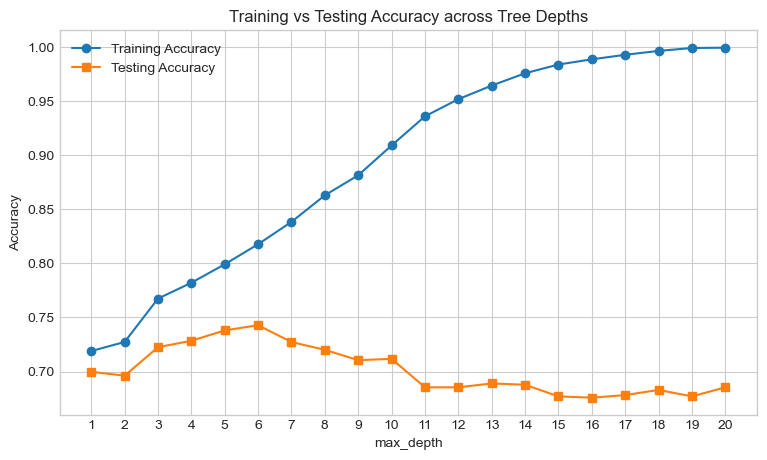

In [7]:
depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

# Plot training vs testing accuracy across depths
plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, marker='o', label='Training Accuracy')
plt.plot(depths, test_scores, marker='s', label='Testing Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy across Tree Depths')
plt.xticks(list(depths))
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# Pick the depth with the best testing accuracy as our "good fit"
best_depth = depths[int(np.argmax(test_scores))]
print(f"Optimal max_depth (best test accuracy): {best_depth}")

goodfit_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
goodfit_model.fit(X_train, y_train)

train_acc_good = accuracy_score(y_train, goodfit_model.predict(X_train))
test_acc_good  = accuracy_score(y_test, goodfit_model.predict(X_test))

print(f"\nGood Fit (max_depth={best_depth})")
print(f"Training Accuracy: {train_acc_good:.4f}")
print(f"Testing Accuracy : {test_acc_good:.4f}")


Optimal max_depth (best test accuracy): 6

Good Fit (max_depth=6)
Training Accuracy: 0.8177
Testing Accuracy : 0.7428


## 8. Comparing All Three Models

Let's summarize training vs. testing accuracy for the three scenarios side by side.
A small gap between train/test accuracy (Good Fit) is what we're aiming for.


In [9]:
comparison = pd.DataFrame({
    "Model": ["Underfitting (depth=1)", f"Good Fit (depth={best_depth})", "Overfitting (depth=None)"],
    "Train Accuracy": [train_acc_under, train_acc_good, train_acc_over],
    "Test Accuracy":  [test_acc_under, test_acc_good, test_acc_over],
})
comparison["Train-Test Gap"] = comparison["Train Accuracy"] - comparison["Test Accuracy"]
comparison


,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Underfitting (depth=1),0.718946,0.699761,0.019186
1,Good Fit (depth=6),0.817719,0.742823,0.074896
2,Overfitting (depth=None),1.000000,0.680622,0.319378


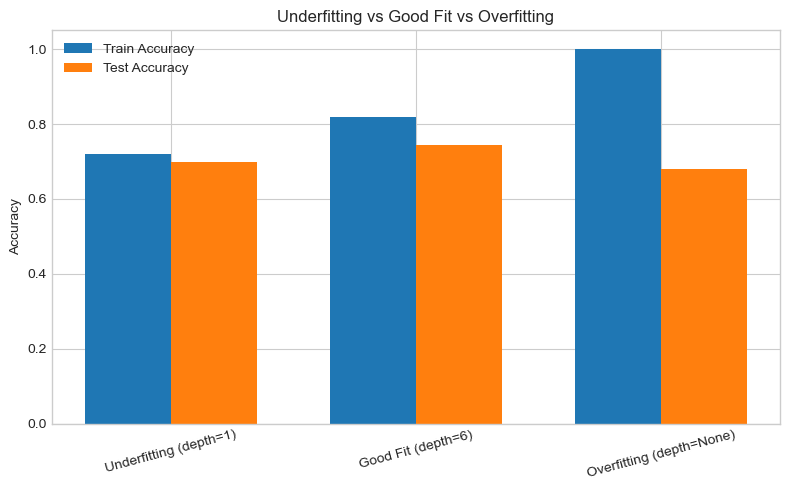

In [10]:
# Visual comparison
x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, comparison["Train Accuracy"], width, label="Train Accuracy")
plt.bar(x + width/2, comparison["Test Accuracy"], width, label="Test Accuracy")
plt.xticks(x, comparison["Model"], rotation=15)
plt.ylabel("Accuracy")
plt.title("Underfitting vs Good Fit vs Overfitting")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Hyperparameter Tuning with `GridSearchCV`

Beyond `max_depth`, several other Decision Tree hyperparameters control model
complexity and help us move from overfitting/underfitting towards a good fit:

| Hyperparameter | Effect |
|---|---|
| `max_depth` | Maximum depth of the tree. Lower = simpler (risk underfit), Higher = complex (risk overfit) |
| `min_samples_split` | Minimum samples required to split an internal node. Higher = simpler tree |
| `min_samples_leaf` | Minimum samples required to be at a leaf node. Higher = smoother, less overfit |
| `criterion` | Function to measure split quality (`gini` or `entropy`) |

We use `GridSearchCV` with cross-validation to search over combinations of these
hyperparameters and pick the combination that generalizes best.


In [11]:
param_grid = {
    'max_depth': [3, 5, 7, 9, 11, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                 # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.7776


In [12]:
# Evaluate the tuned model on the held-out test set
best_model = grid_search.best_estimator_

train_acc_tuned = accuracy_score(y_train, best_model.predict(X_train))
test_acc_tuned  = accuracy_score(y_test, best_model.predict(X_test))

print(f"Tuned Model — Training Accuracy: {train_acc_tuned:.4f}")
print(f"Tuned Model — Testing Accuracy : {test_acc_tuned:.4f}")

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, best_model.predict(X_test), target_names=["Young", "Old"]))


Tuned Model — Training Accuracy: 0.8126
Tuned Model — Testing Accuracy : 0.7440

Classification Report (Test Set):

              precision    recall  f1-score   support

       Young       0.77      0.87      0.82       546
         Old       0.68      0.50      0.58       290

    accuracy                           0.74       836
   macro avg       0.72      0.69      0.70       836
weighted avg       0.74      0.74      0.73       836



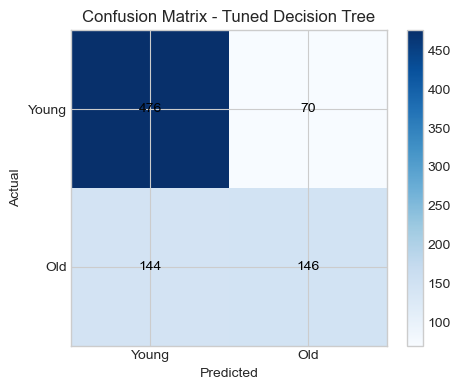

In [13]:
# Confusion matrix for the tuned model
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Tuned Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Young', 'Old'])
plt.yticks([0, 1], ['Young', 'Old'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar()
plt.tight_layout()
plt.show()


### (Optional) Visualize the Top of the Tuned Tree

Plotting the first couple of levels of the tuned tree gives an intuitive sense
of the splits it learned.


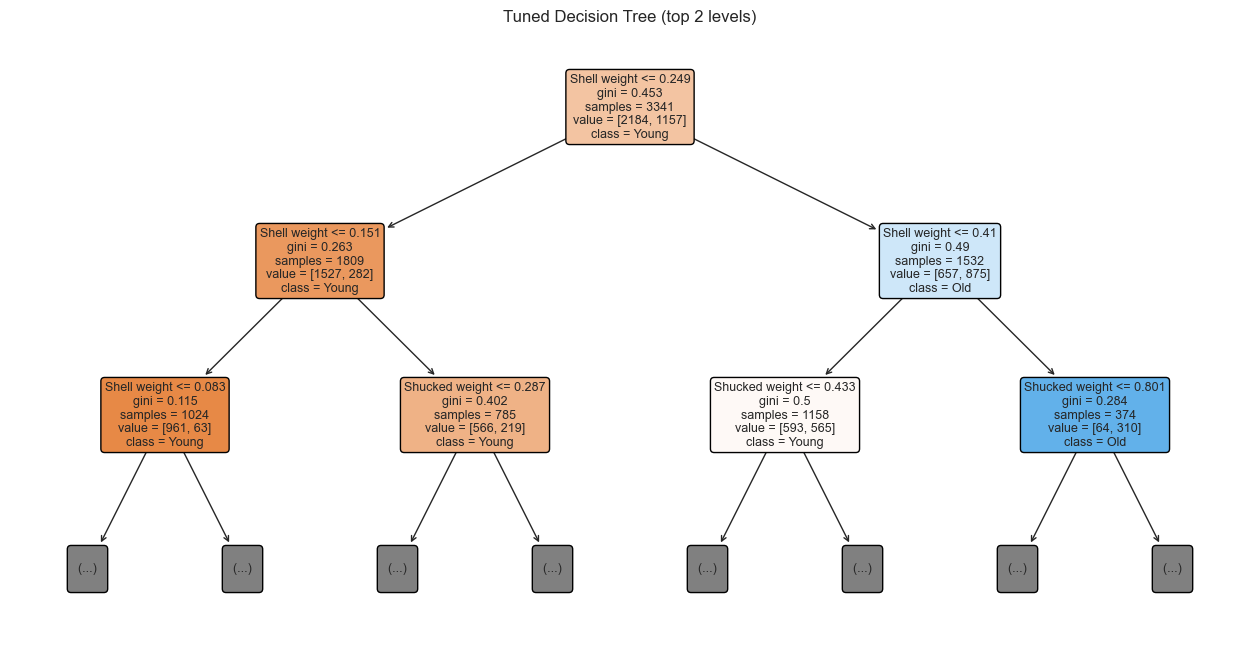

In [15]:
plt.figure(figsize=(16, 8))
plot_tree(
    best_model,
    max_depth=2,             # only show top 2 levels for readability
    feature_names=X.columns.tolist(),
    class_names=["Young", "Old"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Tuned Decision Tree (top 2 levels)")
plt.show()


## 10. Model Improvement Strategies

Once you've identified whether a model is underfitting or overfitting, here are
common strategies to improve it:

### If the model is Underfitting
- **Increase model complexity**: raise `max_depth`, reduce `min_samples_leaf`.
- **Add more relevant features** or engineer better ones.
- **Reduce regularization** (if any is applied).
- **Train longer / use a more expressive model** (e.g., switch from a shallow
  tree to an ensemble like Random Forest or Gradient Boosting).

### If the model is Overfitting
- **Prune the tree**: limit `max_depth`, increase `min_samples_split` /
  `min_samples_leaf`.
- **Use cross-validation** to select hyperparameters instead of testing on the
  same split repeatedly.
- **Use ensemble methods** (Random Forest, Bagging, Gradient Boosting) to
  average out variance from individual trees.
- **Get more training data**, if possible, so the model can't simply memorize it.
- **Feature selection**: remove noisy or irrelevant features.
- **Cost-complexity pruning** (`ccp_alpha` in `DecisionTreeClassifier`) explicitly
  penalizes tree complexity.

### General Best Practices
- Always compare **training vs. testing (or cross-validation) performance**,
  never just training performance.
- Use **k-fold cross-validation** for a more robust estimate of generalization.
- Track the **train-test gap** — a large gap signals overfitting even if test
  accuracy looks "okay".
- Start simple, then increase complexity only as needed (Occam's razor).


## 11. Practice Questions

1. Why does a Decision Tree with `max_depth=1` underfit the Abalone dataset?
   What does its training accuracy being close to its testing accuracy tell you?

2. In the overfitting demo (`max_depth=None`), why is training accuracy so much
   higher than testing accuracy? What is happening to the tree's leaves?

3. Looking at the training-vs-testing accuracy plot across depths, at what
   depth does testing accuracy start to plateau or decline while training
   accuracy keeps increasing? What does that tell you about the good fit range?

4. Explain in your own words how `min_samples_leaf` and `min_samples_split`
   help control overfitting.

5. Why might `criterion='entropy'` give slightly different results than
   `criterion='gini'`? (Hint: think about how each measures impurity.)

6. `GridSearchCV` used 5-fold cross-validation. Why is cross-validation
   preferred over a single train-test split when tuning hyperparameters?

7. Besides Decision Trees, name two ensemble methods that typically reduce
   overfitting compared to a single deep tree, and briefly explain why.

8. If you had more time/data, what additional preprocessing (e.g., feature
   engineering from `Length`, `Diameter`, `Height`, or the weight columns)
   might improve model performance on the Abalone dataset?

9. Try adding `ccp_alpha` (cost-complexity pruning) to the hyperparameter grid.
   How does it affect the best model's training vs. testing accuracy?

10. Re-run the good-fit search using 3-class labels instead of binary
    (e.g., Young / Adult / Old based on `Rings`). Does the optimal `max_depth`
    change? Why might it?
